## E-Commerce Customer Churn Analysis
In this project I am analyzing 100K+ orders from Olist, a Brazilian
e-commerce platform, to identify customers at risk of churning using
RFM segmentation.

Saving olist_customers_dataset.csv to olist_customers_dataset (1).csv
Saving olist_order_items_dataset.csv to olist_order_items_dataset.csv
Saving olist_order_payments_dataset.csv to olist_order_payments_dataset.csv
Saving olist_orders_dataset.csv to olist_orders_dataset.csv


In [5]:
orders = pd.read_csv('olist_orders_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')

print("✅ Orders:", orders.shape)
print("✅ Customers:", customers.shape)
print("✅ Order Items:", order_items.shape)
print("✅ Payments:", payments.shape)

✅ Orders: (99441, 8)
✅ Customers: (99441, 5)
✅ Order Items: (112650, 7)
✅ Payments: (103886, 5)


In [6]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [7]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [8]:
# these columns were showing as object type so i converted them to actual dates

date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

#confirming date columns changed from object to datetime64
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [9]:
# Counting how many orders are in each status
print(orders['order_status'].value_counts())

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [10]:
# Checking if any order_id is appearing more than once (removing duplicates)
duplicates = orders['order_id'].duplicated().sum()
print("Duplicate orders:", duplicates)

Duplicate orders: 0


In [11]:
print(orders['order_status'].value_counts())

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [12]:
# keeping only delivered orders, cancelled ones will mess up the analysis
orders_delivered = orders[orders['order_status'] == 'delivered']

print("Total orders:", len(orders))
print("Delivered orders:", len(orders_delivered))
print("Removed:", len(orders) - len(orders_delivered), "non-delivered orders")

Total orders: 99441
Delivered orders: 96478
Removed: 2963 non-delivered orders


In [13]:
# joining all 4 tables into one master table

# Step 1: Join orders with customers
df = orders_delivered.merge(customers, on='customer_id', how='left')

# Step 2: Join with order items
df = df.merge(order_items, on='order_id', how='left')

# Step 3: Join with payments
df = df.merge(payments, on='order_id', how='left')

print("Final merged table shape:", df.shape)
print(df.head())

Final merged table shape: (115038, 22)
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
2  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
3  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
4  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp   order_approved_at  \
0    delivered      2017-10-02 10:56:33 2017-10-02 11:07:15   
1    delivered      2017-10-02 10:56:33 2017-10-02 11:07:15   
2    delivered      2017-10-02 10:56:33 2017-10-02 11:07:15   
3    delivered      2018-07-24 20:41:37 2018-07-26 03:24:27   
4    delivered      2018-08-08 08:38:49 2018-08-08 08:55:23   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2017

In [14]:
# Check missing values in each column
missing = df.isnull().sum()
print(missing[missing > 0])  # Only show columns that have missing values

order_approved_at                15
order_delivered_carrier_date      2
order_delivered_customer_date     8
payment_sequential                3
payment_type                      3
payment_installments              3
payment_value                     3
dtype: int64


In [15]:
df=df.dropna()

print("Rows before:", 115038)
print("Rows after:", len(df))
print("Rows removed:", 115038 - len(df))

Rows before: 115038
Rows after: 115011
Rows removed: 27


In [16]:
# Get summary statistics for numeric columns
df[['price', 'freight_value', 'payment_value']].describe()

,price,freight_value,payment_value
count,115011.000000,115011.000000,115011.000000
mean,120.081819,19.996013,171.918390
std,183.043451,15.744668,266.133022
min,0.850000,0.000000,0.000000
25%,39.900000,13.080000,60.850000
50%,74.900000,16.280000,108.190000
75%,133.000000,21.180000,188.940000
max,6735.000000,409.680000,13664.080000


## Exploratory Data Analysis
First I want to understand the data before jumping into analysis -
checking distributions, revenue trends and top categories.

In [18]:
import matplotlib.pyplot as plt

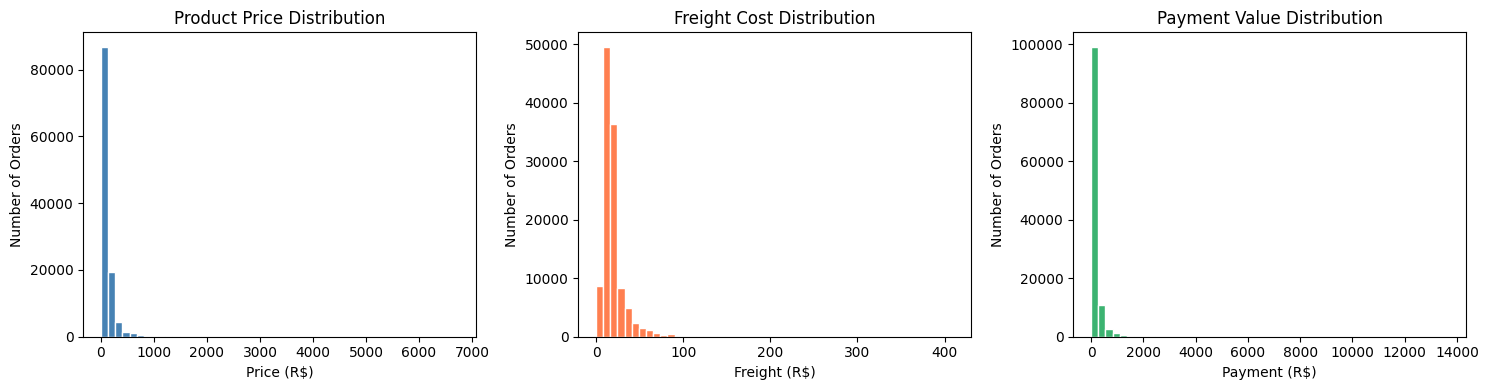

✅ Chart saved!


In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Product Price Distribution')
axes[0].set_xlabel('Price (R$)')
axes[0].set_ylabel('Number of Orders')

axes[1].hist(df['freight_value'], bins=50, color='coral', edgecolor='white')
axes[1].set_title('Freight Cost Distribution')
axes[1].set_xlabel('Freight (R$)')
axes[1].set_ylabel('Number of Orders')

axes[2].hist(df['payment_value'], bins=50, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Payment Value Distribution')
axes[2].set_xlabel('Payment (R$)')
axes[2].set_ylabel('Number of Orders')

plt.tight_layout()
plt.savefig('distribution_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

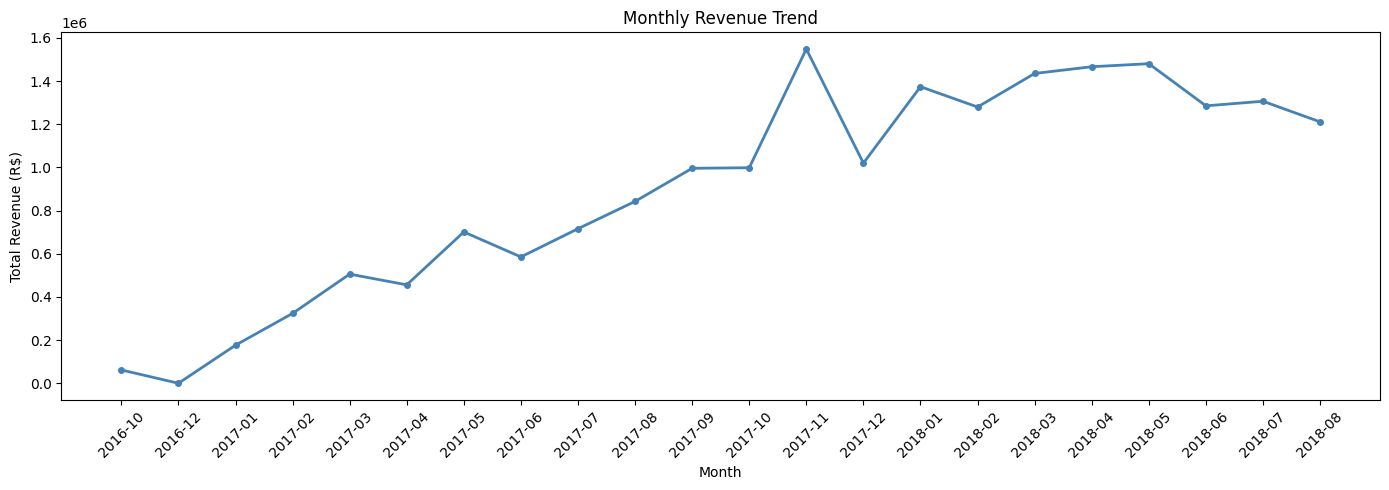

✅ Chart saved!


In [20]:
# Extract year and month from purchase date
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')

# Calculate total revenue per month
monthly_revenue = df.groupby('month')['payment_value'].sum().reset_index()
monthly_revenue['month'] = monthly_revenue['month'].astype(str)

# Plot
plt.figure(figsize=(14, 5))
plt.plot(monthly_revenue['month'], monthly_revenue['payment_value'],
         color='steelblue', marker='o', linewidth=2, markersize=4)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

In [22]:
from google.colab import files
uploaded = files.upload()

Saving olist_products_dataset.csv to olist_products_dataset.csv
Saving product_category_name_translation.csv to product_category_name_translation.csv


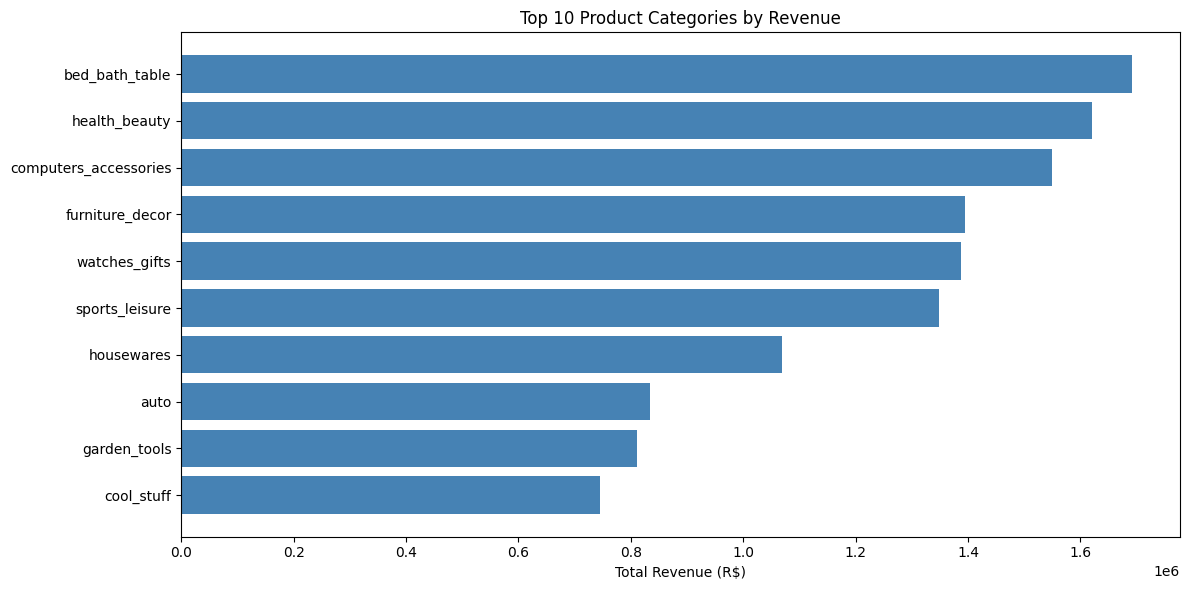

✅ Chart saved!


In [23]:
# Merge product category names
products = pd.read_csv('olist_products_dataset.csv')
category_translation = pd.read_csv('product_category_name_translation.csv')

# Join products with english category names
products = products.merge(category_translation, on='product_category_name', how='left')

# Join with our master dataframe
df = df.merge(products[['product_id','product_category_name_english']],
              on='product_id', how='left')

# Calculate revenue by category
category_revenue = df.groupby('product_category_name_english')['payment_value'].sum()
category_revenue = category_revenue.sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(12, 6))
plt.barh(category_revenue.index[::-1], category_revenue.values[::-1],
         color='steelblue')
plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Total Revenue (R$)')
plt.tight_layout()
plt.savefig('category_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

## RFM Analysis
RFM stands for Recency, Frequency and Monetary. I am using this to
segment customers based on their buying behaviour and identify
who is at risk of churning.

In [24]:
import datetime

# We use the latest date in the dataset as "today"
snapshot_date = df['order_purchase_timestamp'].max() + datetime.timedelta(days=1)
print("Snapshot date:", snapshot_date)

# Calculate RFM for each unique customer
rfm = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,  # Recency
    'order_id': 'nunique',   # Frequency
    'payment_value': 'sum'   # Monetary
}).reset_index()

# Rename columns clearly
rfm.columns = ['customer_id', 'recency', 'frequency', 'monetary']

print(rfm.shape)
print(rfm.head())

Snapshot date: 2018-08-30 15:00:37
(93335, 4)
                        customer_id  recency  frequency  monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19
2  0000f46a3911fa3c0805444483337064      537          1     86.22
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62
4  0004aac84e0df4da2b147fca70cf8255      288          1    196.89


In [25]:
# Score recency - lower days = better = higher score
# So we reverse it with ascending=False
rfm['r_score'] = pd.qcut(rfm['recency'], q=5,
                          labels=[5, 4, 3, 2, 1])

# Score frequency - higher orders = higher score
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5,
                          labels=[1, 2, 3, 4, 5])

# Score monetary - higher spend = higher score
rfm['m_score'] = pd.qcut(rfm['monetary'], q=5,
                          labels=[1, 2, 3, 4, 5])

# Convert to numbers
rfm['r_score'] = rfm['r_score'].astype(int)
rfm['f_score'] = rfm['f_score'].astype(int)
rfm['m_score'] = rfm['m_score'].astype(int)

# Combined RFM score
rfm['rfm_score'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score']

print(rfm.head(10))
print("\nRFM Score range:", rfm['rfm_score'].min(), "to", rfm['rfm_score'].max())

                        customer_id  recency  frequency  monetary  r_score  \
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90        4   
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19        4   
2  0000f46a3911fa3c0805444483337064      537          1     86.22        1   
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62        2   
4  0004aac84e0df4da2b147fca70cf8255      288          1    196.89        2   
5  0004bd2a26a76fe21f786e4fbd80607f      146          1    166.98        4   
6  00050ab1314c0e55a6ca13cf7181fecf      132          1     35.38        4   
7  00053a61a98854899e70ed204dd4bafe      183          1    838.36        3   
8  0005e1862207bf6ccc02e4228effd9a0      543          1    150.12        1   
9  0005ef4cd20d2893f0d9fbd94d3c0d97      170          1    129.76        4   

   f_score  m_score  rfm_score  
0        1        4          9  
1        1        1          6  
2        1        2          4  
3        

In [26]:
# Segment customers based on their rfm_score
def assign_segment(score):
    if score >= 13:
        return 'Champions'
    elif score >= 10:
        return 'Loyal Customers'
    elif score >= 7:
        return 'At Risk'
    elif score >= 5:
        return 'Hibernating'
    else:
        return 'Lost'

rfm['segment'] = rfm['rfm_score'].apply(assign_segment)

# Count customers in each segment
segment_counts = rfm['segment'].value_counts()
print(segment_counts)

segment
At Risk            38343
Loyal Customers    31582
Hibernating        12295
Champions           7975
Lost                3140
Name: count, dtype: int64


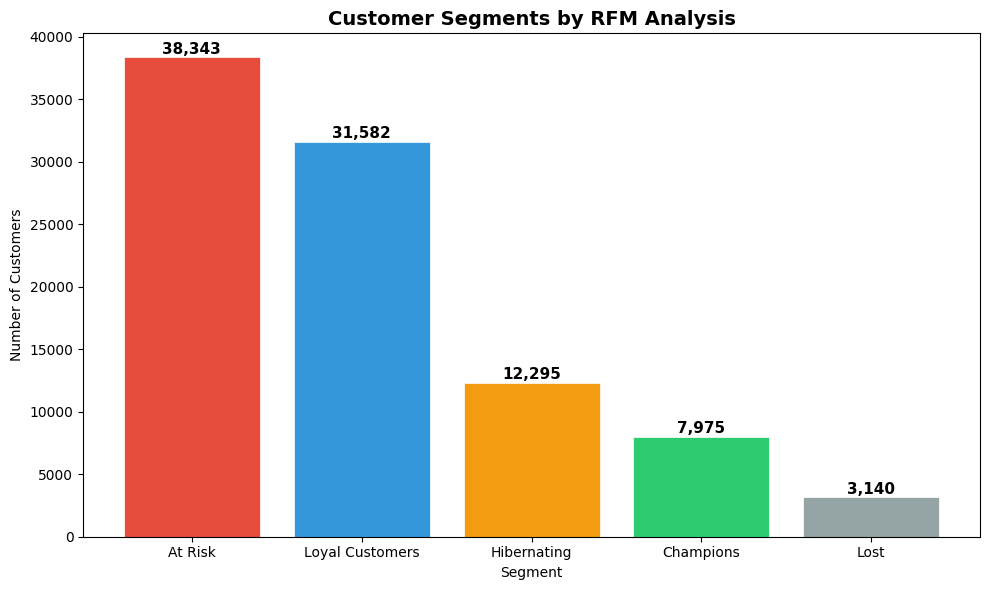

✅ Chart saved!


In [27]:
# Define colors for each segment
colors = {
    'Champions': '#2ecc71',
    'Loyal Customers': '#3498db',
    'At Risk': '#e74c3c',
    'Hibernating': '#f39c12',
    'Lost': '#95a5a6'
}

# Plot segment distribution
plt.figure(figsize=(10, 6))
bars = plt.bar(segment_counts.index,
               segment_counts.values,
               color=[colors[s] for s in segment_counts.index],
               edgecolor='white',
               linewidth=0.5)

# Add count labels on top of each bar
for bar, count in zip(bars, segment_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 300,
             f'{count:,}',
             ha='center', fontsize=11, fontweight='bold')

plt.title('Customer Segments by RFM Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

In [28]:
# Calculate average monetary value per segment
segment_revenue = rfm.groupby('segment')['monetary'].agg(['mean', 'sum']).round(2)
segment_revenue.columns = ['avg_spend', 'total_spend']
segment_revenue = segment_revenue.sort_values('total_spend', ascending=False)
print(segment_revenue)

                 avg_spend  total_spend
segment                                
Loyal Customers     279.89   8839527.88
At Risk             158.08   6061340.60
Champions           480.64   3833106.31
Hibernating          72.19    887565.03
Lost                 48.08    150966.08


In [29]:
# Save the complete RFM table for Tableau dashboard
rfm.to_csv('rfm_segments.csv', index=False)
print("✅ RFM data saved!")
print("Shape:", rfm.shape)
print("\nColumns:", rfm.columns.tolist())

✅ RFM data saved!
Shape: (93335, 9)

Columns: ['customer_id', 'recency', 'frequency', 'monetary', 'r_score', 'f_score', 'm_score', 'rfm_score', 'segment']


In [31]:
from google.colab import files

files.download('distribution_plots.png')
files.download('monthly_revenue.png')
files.download('category_revenue.png')
files.download('rfm_segments.png')
files.download('rfm_segments.csv')

print("✅ All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded!


## Key Findings
- 41% of customers (38,343) are At Risk of churning
- At Risk segment represents R$6M in revenue at risk
- Most customers bought only once showing high one-time buyer rate
- Champions spend 3x more than average customers (R$480 vs R$158)
- November 2017 Black Friday spike showed 50% revenue surge